In [109]:
import numpy as np
import os
import pandas as pd

In [110]:
seed = 42
np.random.seed(seed)


In [111]:
housing_dataframe = pd.read_csv('../dataset/housing.csv')
housing_dataframe.head()

housing = housing_dataframe.copy()

In [112]:
# Embaralha o dataframe por completo.
# Caso usa-se n=10, retornaria apenas 10 linhas aleatórias, não embaralhando todo o dataframe
housing_dataframe.sample(frac=1, random_state=seed)

housing_dataframe.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [113]:
housing_dataframe['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [114]:
housing_dataframe.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

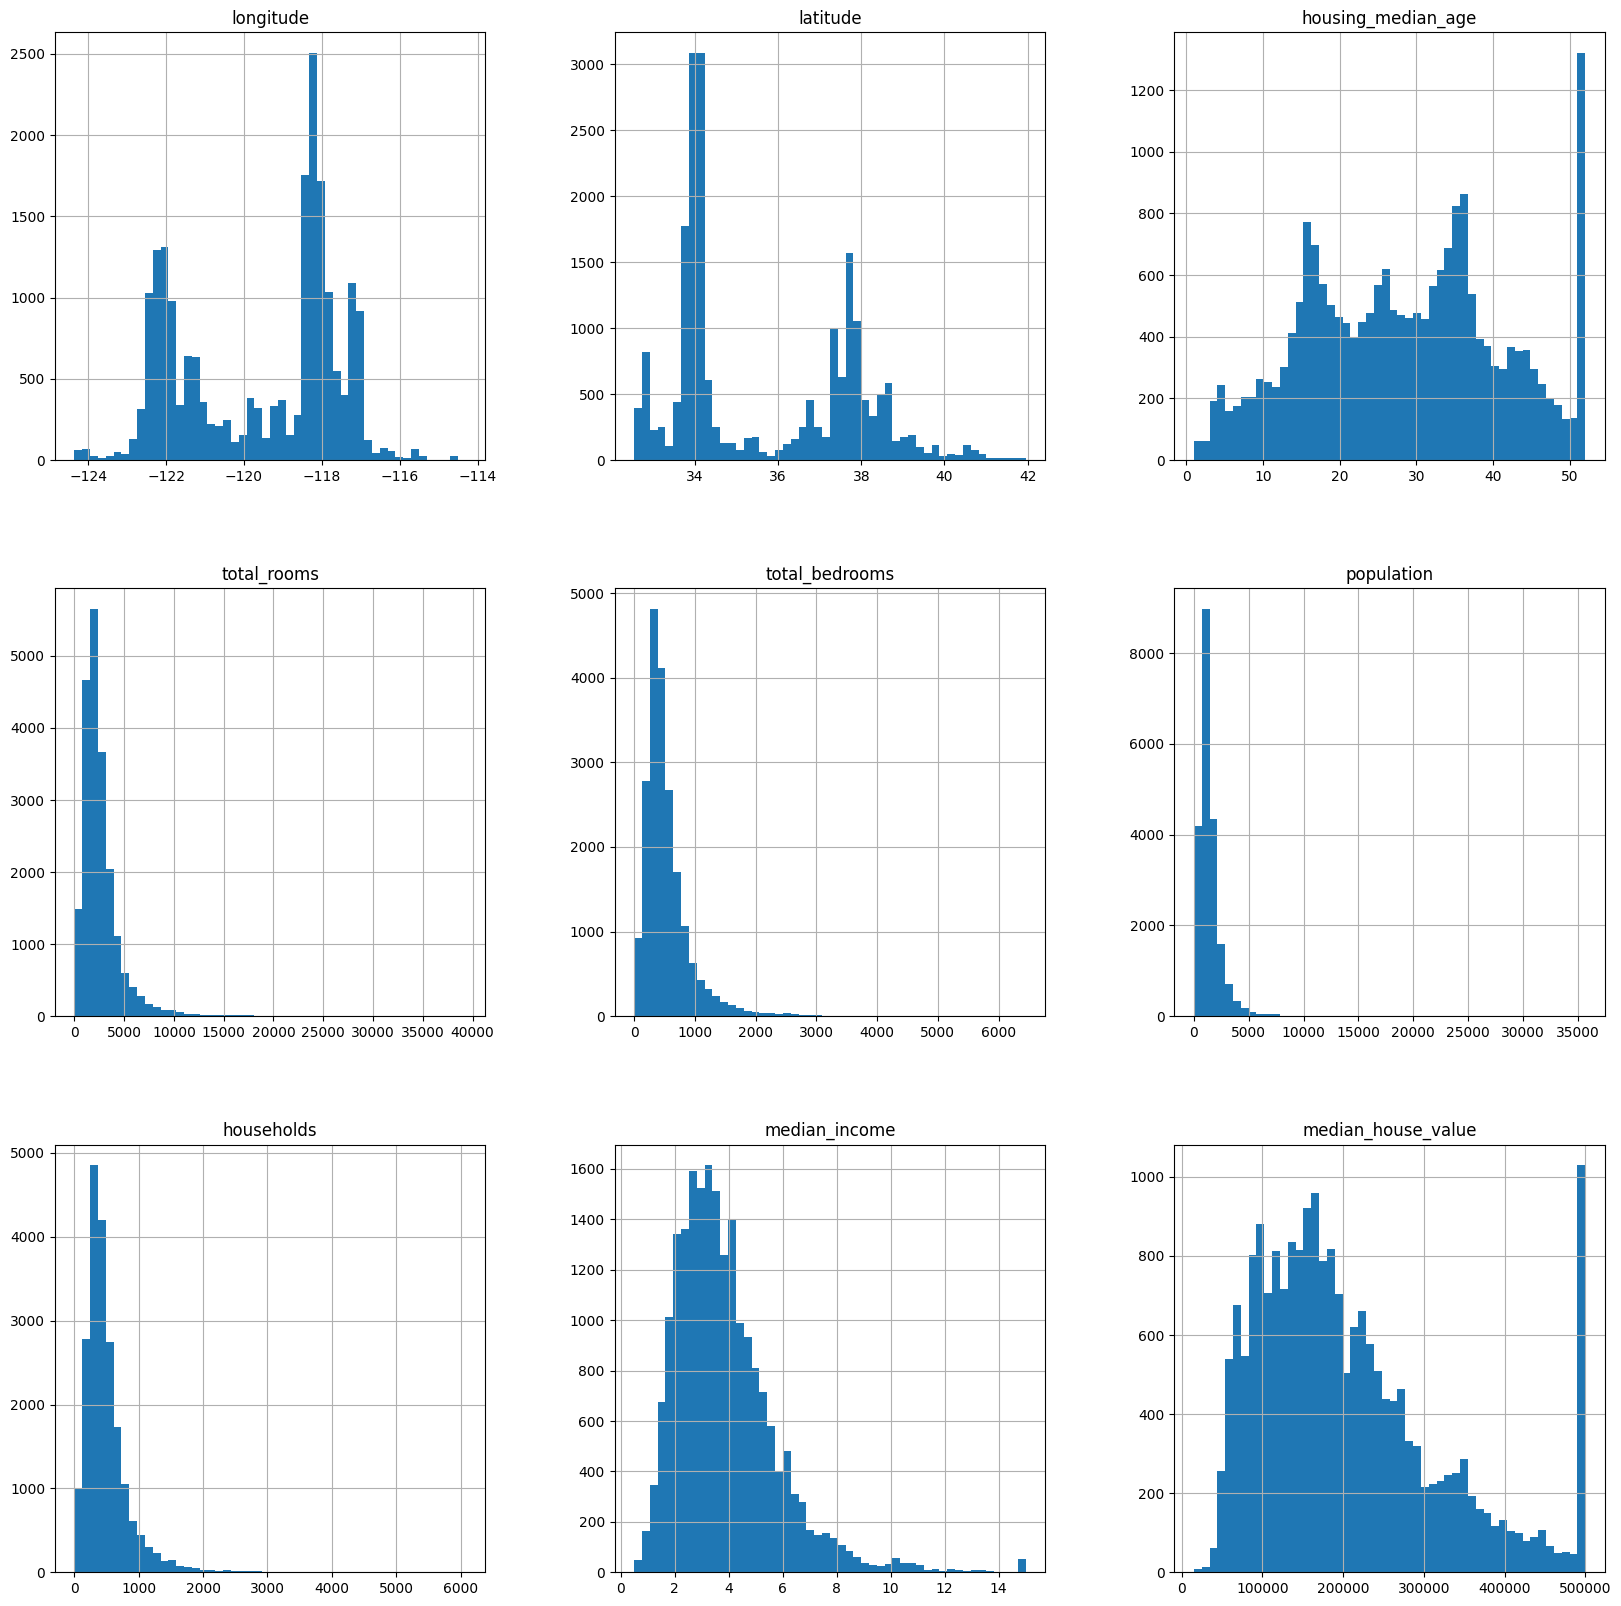

In [115]:
import matplotlib.pyplot as plt

housing_dataframe.hist(bins=50, figsize=(20,20))

In [116]:

from sklearn.model_selection import train_test_split

treino, teste = train_test_split(housing_dataframe, random_state=seed, test_size=0.2)

In [117]:
# Média da renda
mean = np.mean(housing_dataframe['median_income'])
print(f'Média da renda é {mean}')

# Desvio padrão Renda
std = np.std(housing_dataframe['median_income'])
print(f'O desvio padrão da renda é {std}')

Média da renda é 3.8706710029069766
O desvio padrão da renda é 1.8997756945748738


<Axes: >

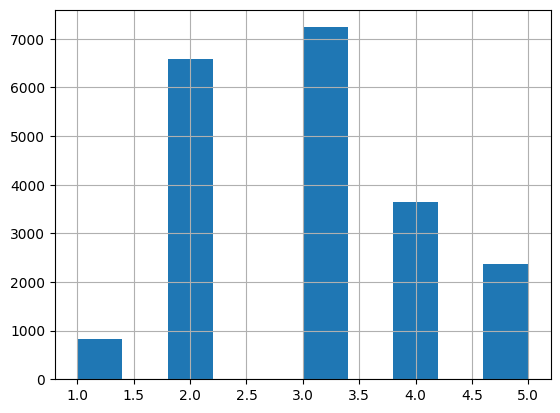

In [118]:
# Estratificando dados (Dividir conjunto de dados em grupos)

housing_dataframe['income_cat'] = pd.cut(housing_dataframe['median_income'], bins=[0., 1.5, 3.0,  4.5, 6., np.inf], labels=[1,2,3,4,5])

housing_dataframe['income_cat'].hist()



In [119]:
housing_dataframe['income_cat'].value_counts().sort_index()

income_cat
1     822
2    6581
3    7236
4    3639
5    2362
Name: count, dtype: int64

In [120]:
from sklearn.model_selection import StratifiedShuffleSplit

# n_splits = 1, vai gerar apenas um par de treino e teste

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)

In [121]:
for train_index, test_index in split.split(housing_dataframe, housing_dataframe['income_cat']):
    strat_train_set = housing_dataframe.loc[train_index]
    strat_test_set = housing_dataframe.loc[test_index]

In [122]:
strat_test_set['income_cat'].value_counts() / len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [123]:
housing_dataframe['income_cat'].value_counts() / len(housing_dataframe)

income_cat
3    0.350581
2    0.318847
4    0.176308
5    0.114438
1    0.039826
Name: count, dtype: float64

In [124]:
def income_cat_proportion(data: pd.DataFrame):
    return data['income_cat'].value_counts() / len(data)

In [125]:
income_cat_proportion(housing_dataframe)


income_cat
3    0.350581
2    0.318847
4    0.176308
5    0.114438
1    0.039826
Name: count, dtype: float64

In [126]:
# Vamos gerar novamente o conjunto de teste usando uma amostragem aleatória
train_set, test_set = train_test_split(housing_dataframe, random_state=seed, test_size=0.2)

In [127]:
compare_props = pd.DataFrame({
    "Geral": income_cat_proportion(housing_dataframe),
    "Estratificado": income_cat_proportion(strat_test_set),
    "Aleatorio": income_cat_proportion(test_set)
})

In [128]:

compare_props["Aleatorio"] = 100 * compare_props["Aleatorio"] / compare_props['Geral'] - 100
compare_props["Estratificado %erro"] = 100* compare_props["Estratificado"] / compare_props['Geral'] - 100

compare_props.sort_index()



,Geral,Estratificado,Aleatorio,Estratificado %erro
income_cat,,,,
1,0.039826,0.039971,0.973236,0.364964
2,0.318847,0.318798,1.732260,-0.015195
3,0.350581,0.350533,2.266446,-0.013820
4,0.176308,0.176357,-5.056334,0.027480
5,0.114438,0.114341,-4.318374,-0.084674


In [129]:
housing.drop(columns=['ocean_proximity'], inplace=True)

corr_matrix = housing.corr()

In [130]:
corr_matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000
